In [1]:
!pip install -U pandas yt-dlp matplotlib

   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   ------------ --------------------------- 1.0/3.3 MB 5.1 MB/s eta 0:00:01
   ------------------------- -------------- 2.1/3.3 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 3.3/3.3 MB 5.4 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yt_dlp

In [3]:
base_dir = "."
raw_csv_dir = os.path.join(base_dir, "raw_csv")
raw_outputs_dir = os.path.join(base_dir, "raw_outputs")

os.makedirs(raw_csv_dir, exist_ok=True)
os.makedirs(raw_outputs_dir, exist_ok=True)

print("raw_csv_dir:", raw_csv_dir)
print("raw_outputs_dir:", raw_outputs_dir)

raw_csv_dir: .\raw_csv
raw_outputs_dir: .\raw_outputs


In [4]:
queries = [
    "bird warning call",
    "territorial bird call",
    "alarm call animal",
    "animal warning sound urban",
    "territorial animal sound"
]

target_per_query = 80

print("Queries:", queries)
print("Target per query:", target_per_query)

Queries: ['bird warning call', 'territorial bird call', 'alarm call animal', 'animal warning sound urban', 'territorial animal sound']
Target per query: 80


In [5]:
def search_youtube_metadata(query, max_results=80):
    ydl_opts = {
        "quiet": True,
        "extract_flat": True,
        "skip_download": True,
        "forcejson": False,
        "dump_single_json": False,
    }

    search_term = f"ytsearch{max_results}:{query}"
    rows = []

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(search_term, download=False)

    entries = info.get("entries", []) if info else []

    for item in entries:
        rows.append({
            "query": query,
            "video_id": item.get("id", ""),
            "title": item.get("title", ""),
            "channel": item.get("channel", "") or item.get("uploader", ""),
            "duration": item.get("duration", None),
            "view_count": item.get("view_count", None),
            "upload_date": item.get("upload_date", ""),
            "url": item.get("url", ""),
            "webpage_url": item.get("webpage_url", ""),
        })

    return rows

In [6]:
all_rows = []

for query in queries:
    print("Searching:", query)
    rows = search_youtube_metadata(query, max_results=target_per_query)
    print("Found:", len(rows))
    all_rows.extend(rows)

df_raw = pd.DataFrame(all_rows)

print("Raw rows:", len(df_raw))
display(df_raw.head())

Searching: bird warning call
Found: 80
Searching: territorial bird call
Found: 80
Searching: alarm call animal
Found: 80
Searching: animal warning sound urban
Found: 80
Searching: territorial animal sound
Found: 80
Raw rows: 400


,query,video_id,title,channel,duration,view_count,upload_date,url,webpage_url
0,bird warning call,dvK-DujvpSY,White bellbird: listen to the world's loudest ...,Guardian News,31.0,9885069.0,,https://www.youtube.com/watch?v=dvK-DujvpSY,
1,bird warning call,cPIIVjkp7k0,Bluebird Alarm Call,Wild Birds Unlimited Macomb,12.0,26065.0,,https://www.youtube.com/watch?v=cPIIVjkp7k0,
2,bird warning call,ga_Ybn_K4rc,Chickadee alarm call (16 alarm call at the end!),Bird Feeder Hub,29.0,13511.0,,https://www.youtube.com/watch?v=ga_Ybn_K4rc,
3,bird warning call,uuxTZN98rHI,"5 bird alarm calls: blackbird, wren, blackcap,...",Watch the Birdie,96.0,30788.0,,https://www.youtube.com/watch?v=uuxTZN98rHI,
4,bird warning call,07zi6M7sCJQ,Hawk sounds to scare birds 🦅 7 hours,PMnaturaly,25333.0,651426.0,,https://www.youtube.com/watch?v=07zi6M7sCJQ,


In [7]:
df_raw = df_raw.drop_duplicates(subset=["video_id"]).reset_index(drop=True)

print("Unique rows:", len(df_raw))

raw_file = os.path.join(raw_csv_dir, "dataset1_raw_youtube.csv")
df_raw.to_csv(raw_file, index=False, encoding="utf-8-sig")

print("Saved file:", raw_file)

Unique rows: 373
Saved file: .\raw_csv\dataset1_raw_youtube.csv


In [8]:
query_counts = df_raw["query"].value_counts().reset_index()
query_counts.columns = ["query", "count"]

display(query_counts)

,query,count
0,bird warning call,80
1,territorial animal sound,76
2,animal warning sound urban,73
3,territorial bird call,72
4,alarm call animal,72


In [9]:
print("Unique rows:", len(df_raw))

if len(df_raw) >= 200:
    print("Good: Dataset 1 has reached 200+ elements.")
else:
    print("Not enough yet. We need more queries or more results per query.")

Unique rows: 373
Good: Dataset 1 has reached 200+ elements.


In [10]:
df_raw["title"] = df_raw["title"].fillna("").astype(str)

display(df_raw[["query", "title", "channel"]].head(30))

,query,title,channel
0,bird warning call,White bellbird: listen to the world's loudest ...,Guardian News
1,bird warning call,Bluebird Alarm Call,Wild Birds Unlimited Macomb
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),Bird Feeder Hub
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",Watch the Birdie
4,bird warning call,Hawk sounds to scare birds 🦅 7 hours,PMnaturaly
5,bird warning call,Bird Calls: Is That An Alarm?,NatureMentor
6,bird warning call,Blackbird alarm call,hebrideanwild
7,bird warning call,Decoding bird calls: What they are REALLY Saying?,Wildlife Wanderings
8,bird warning call,Loud American Robin Alarm Warning Call - Robin...,TheBackyardBirder - Corey Schmaltz
9,bird warning call,Anti Birds Repellent Sound - calls of birds of...,Relax Milleaccendini


In [11]:
df_raw["title_length"] = df_raw["title"].apply(len)

print(df_raw["title_length"].describe())

count    373.000000
mean      54.434316
std       23.146311
min        9.000000
25%       38.000000
50%       54.000000
75%       68.000000
max      100.000000
Name: title_length, dtype: float64


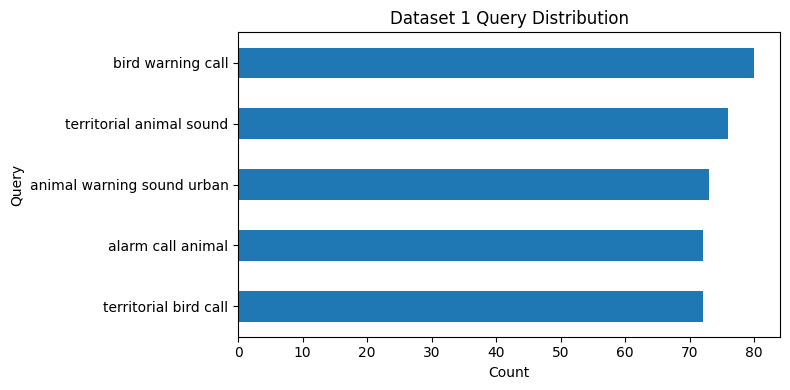

In [12]:
query_plot = df_raw["query"].value_counts().sort_values()

plt.figure(figsize=(8, 4))
query_plot.plot(kind="barh")
plt.title("Dataset 1 Query Distribution")
plt.xlabel("Count")
plt.ylabel("Query")
plt.tight_layout()
plt.show()

In [13]:
overview_file = os.path.join(raw_outputs_dir, "dataset1_raw_overview.csv")
df_raw.to_csv(overview_file, index=False, encoding="utf-8-sig")

print("Saved file:", overview_file)

Saved file: .\raw_outputs\dataset1_raw_overview.csv


In [14]:
duplicate_titles = df_raw["title"].duplicated().sum()
print("Duplicate titles:", duplicate_titles)

Duplicate titles: 1


In [15]:
display(df_raw[["query", "title", "channel"]].sample(20, random_state=42))

,query,title,channel
327,territorial animal sound,Leopard Sounds,Genegeek
33,bird warning call,25 Iconic Bird Sounds,Navarre's Wild Shots
15,bird warning call,Mockingbird alarm / distress / warning call sound,GoTrails
314,territorial animal sound,Coyote Sounds | Animal Sounds with Peter Baeten,Sunville Sounds
57,bird warning call,Predator Hunting Call - Starling Distress - 5 ...,Hotrods & Hunting
239,animal warning sound urban,The Big Five Uk Owls | And How to Recognise t...,WildWoodlands SW
76,bird warning call,Bird calls that get progressively wilder | Aus...,Nature Films by John Kha
119,territorial bird call,MOST BEAUTIFUL PARROTS OF AUSTRALIA 🦜 RELAXING...,Awesome Nature
305,territorial animal sound,Antarctic Animal Sounds,Animals Friends
126,territorial bird call,"Grey Heron (Ardea cinerea) Bird Call & Video, ...",Stories Of The Kruger
